In [2]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


🔄 Chargement des données: 100%|██████████| 50/50 [00:01<00:00, 32.88exp/s]


🔔 Starting Regression/BET_ResNet2
✅ Network Initialized


Testing (regression): 100%|██████████| 313/313 [01:43<00:00,  3.01batch/s, mse=0.0370]


📏 Test MSE (moyenne par échantillon): 0.0970
📏 Test MSE (denormalized): 3.6269


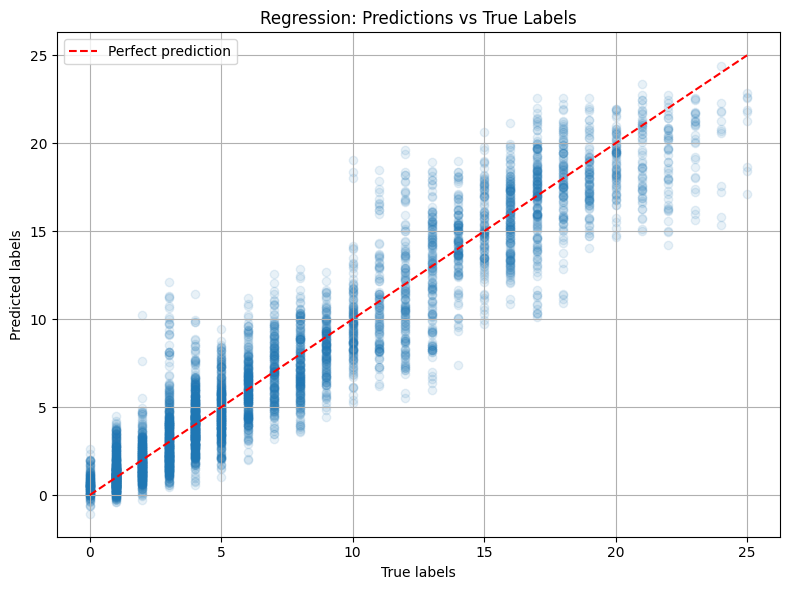

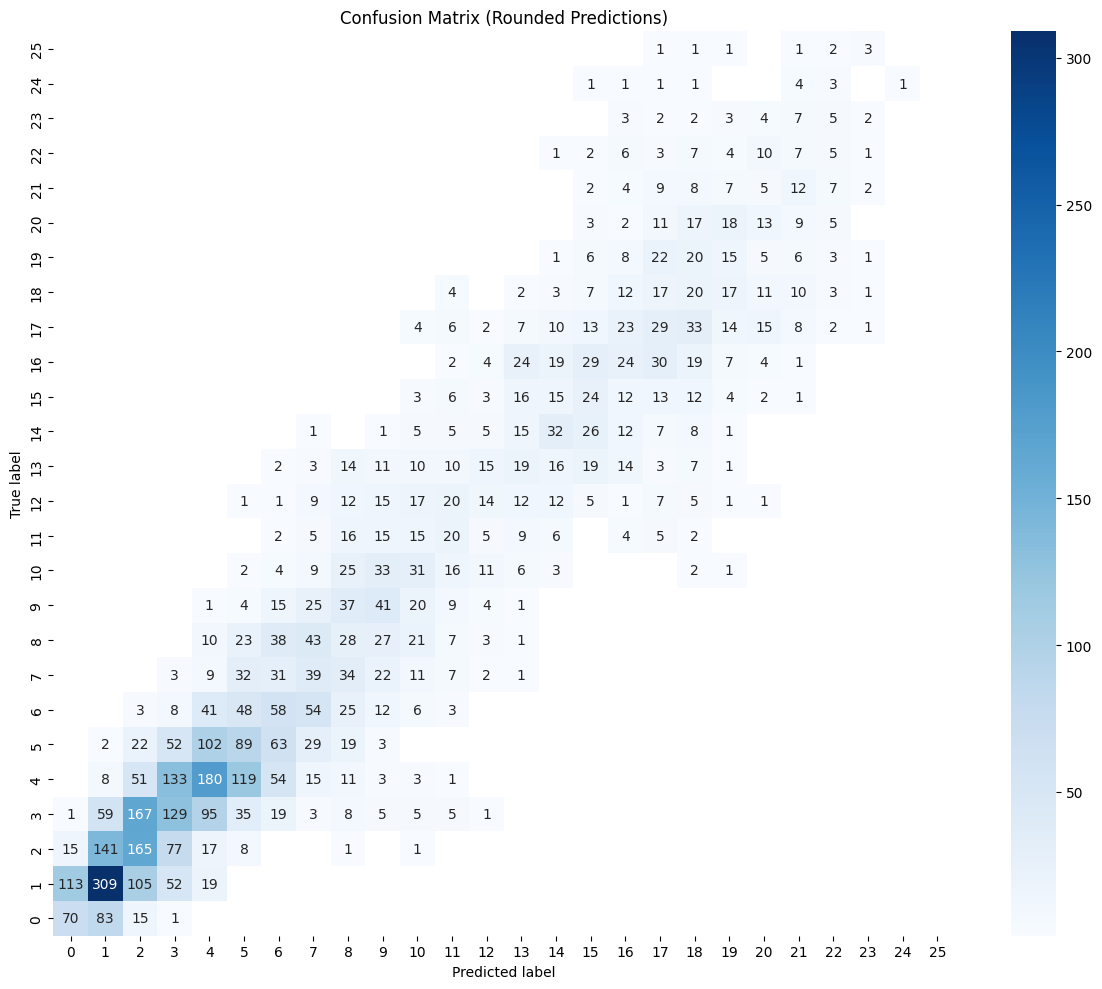

In [9]:
l_exp = [f"Regression/BET_ResNet2"]

data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    #exp = "DefaultExp"
    print(f"🔔 Starting {exp}")
    stream = open(f"exp_list/{exp}.yaml", 'r')
    param  = yaml.safe_load(stream)
    param["TRAINING"]["DEVICE"] = 'mps'

    resultsPath = os.path.join("results", exp)

    # Create the directory
    if not os.path.exists(resultsPath):
        os.makedirs(resultsPath)

    myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

    # Train the network
    #train_losses, val_losses =  myNetwork.train()

    # Test the network
    myNetwork.loadWeight()
    myNetwork.test()   





In [4]:
print(len(myNetwork.dataSetTrain))
print(len(myNetwork.dataSetTest))
print(len(myNetwork.dataSetVal))

39640
4955
4955


In [ ]:
num_params = sum(p.numel() for p in myNetwork.model.parameters())
print(f"Number of parameters: {num_params}") 
# V1 = 2.147.874.498
# V2 = 8.482.754
# V3 = 2.190.530
# V_reg = 2.190.465
# V_reg_48CH = 12.833.441
# V_reg4 = 8.505.697
# V_reg5 = 3.201.769
# Res Net = 11.175.554

Number of parameters: 11175554


[0.20525241 0.10752949 0.07715934 0.05631679 0.04450468 0.03591247
 0.03003784 0.02447284 0.02126515 0.01909217 0.01647887 0.01560713
 0.01329716 0.01277641 0.01137698 0.01067067 0.00999958 0.00921383
 0.00844012 0.00831666 0.00768927 0.00725492 0.00684529 0.00644369
 0.00593513 0.00573227 0.00557303 0.00534603 0.00522005 0.0049539 ]
[0.12257266 0.12203989 0.1128     0.09726012 0.1243928  0.29597606
 0.17094615 0.08408069 0.0866742  0.2195594  0.08041607 0.07971428
 0.08570154 0.07591775 0.1062861  0.09347588 0.08905488 0.0761663
 0.07435926 0.07763519 0.07707059 0.07178252 0.07568288 0.08193948
 0.07519633 0.08252184 0.07287468 0.07021947 0.07393082 0.08160049]


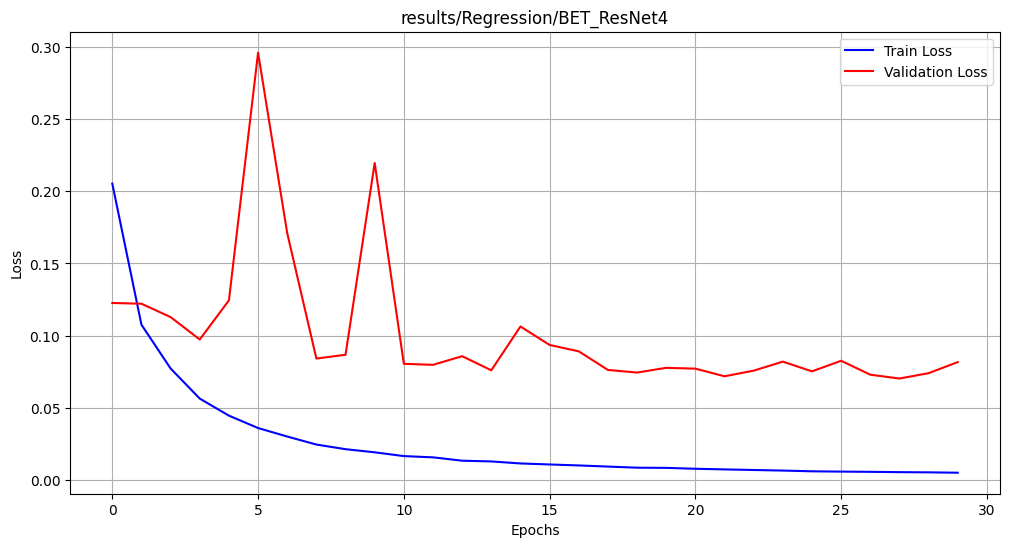

In [8]:
# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)
plot_learning_curves(train_losses, val_losses, resultsPath)